# EA Player Review & Sentiment Analytics

**Simulated EA Product Analyst project** — built to mirror the kind of
analysis a Product Analyst Intern on EA Hyderabad's Slingshot Studios
team would run: turning raw player reviews into decisions about
engagement, retention risk, and live-service health.

**Games covered:** EA SPORTS FC 25, Apex Legends, The Sims 4, Battlefield 2042
**Data:** ~8,000 synthetic player reviews (Jan–Jun 2024), generated with
realistic rating/sentiment correlation and one deliberate "bad patch"
event injected into the Battlefield 2042 data, so the anomaly-detection
section has a real signal to find (see `data/generate_data.py` for how
it's constructed and why real Steam/EA APIs weren't reachable in this
environment).

**What this notebook does, end to end:**
1. EDA on player review volume, ratings, and platform/region mix
2. Sentiment scoring with VADER (lexicon-based)
3. A supervised ML classifier (TF-IDF + Logistic Regression) that
   predicts positive/negative sentiment from review text, with
   train/test split, cross-validation, and a confusion matrix
4. Hypothesis testing: did the Battlefield 2042 patch actually hurt
   sentiment, or is that noise? (Welch's t-test)
5. Correlation & regression: does playtime relate to rating?
6. Player segmentation (KMeans) into casual / regular / power users
7. Anomaly detection on the daily sentiment time series
8. A short volume forecast for the next 14 days
9. Business takeaways, written the way a PA would hand them to a
   producer

## Step 0: Setup & Data Load

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_palette("Set2")

df = pd.read_csv("../data/ea_player_reviews.csv", parse_dates=["review_date"])
print(df.shape)
df.head()

(7921, 11)


,review_id,game,genre,platform,region,rating,review_text,playtime_hours,review_date,is_post_patch_window,user_id
0,100015,Apex Legends,Battle Royale,PC,LATAM,5,Big fan of how squad play turned out. Worth th...,40.8,2024-01-01,False,u_77095
1,100016,Apex Legends,Battle Royale,PC,North America,4,the store prices works as expected. Genuinely ...,113.1,2024-01-01,False,u_62353
2,100017,Apex Legends,Battle Royale,PS4,APAC,4,the UI feels great this week. Would recommend ...,14.4,2024-01-01,False,u_65770
3,100018,Apex Legends,Battle Royale,Xbox Series X,North America,5,Honestly servers is in a good spot. Devs are c...,49.8,2024-01-01,False,u_98056
4,100019,Apex Legends,Battle Royale,PC,LATAM,4,"Been having a lot of fun, graphics is solid. B...",27.7,2024-01-01,False,u_66154


In [2]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
review_id,7921.0,NaN,NaN,NaN,103961.0,100001.0,101981.0,103961.0,105941.0,107921.0,2286.740074
game,7921,4,Battlefield 2042,2057,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genre,7921,4,Shooter,2057,NaN,NaN,NaN,NaN,NaN,NaN,NaN
platform,7921,5,PC,2713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,7921,5,North America,2562,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating,7921.0,NaN,NaN,NaN,3.630476,1.0,3.0,4.0,4.0,5.0,0.78459
review_text,7921,3945,squad play feels great this week. Worth the pr...,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
playtime_hours,7921.0,NaN,NaN,NaN,54.768363,0.3,27.4,46.1,72.9,380.5,37.254922
review_date,7921,NaN,NaN,NaN,2024-03-30 23:34:00.196944,2024-01-01 00:00:00,2024-02-15 00:00:00,2024-04-01 00:00:00,2024-05-14 00:00:00,2024-06-29 00:00:00,NaN
is_post_patch_window,7921,2,False,7730,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 1: Exploratory Data Analysis

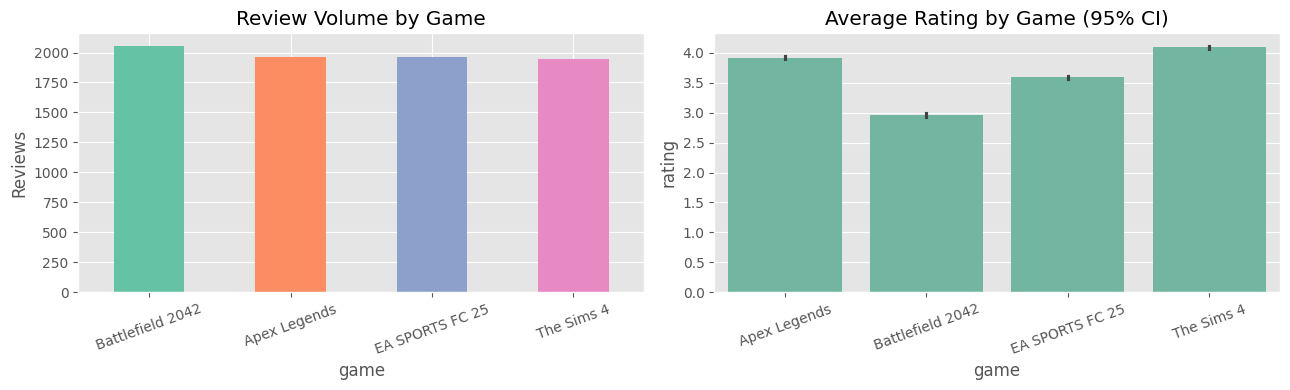

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4))

df["game"].value_counts().plot(kind="bar", ax=axs[0], color=sns.color_palette("Set2"))
axs[0].set_title("Review Volume by Game")
axs[0].set_ylabel("Reviews")
axs[0].tick_params(axis="x", rotation=20)

sns.barplot(data=df, x="game", y="rating", ax=axs[1], errorbar=("ci", 95))
axs[1].set_title("Average Rating by Game (95% CI)")
axs[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("../app/assets_volume_rating.png", dpi=110)
plt.show()

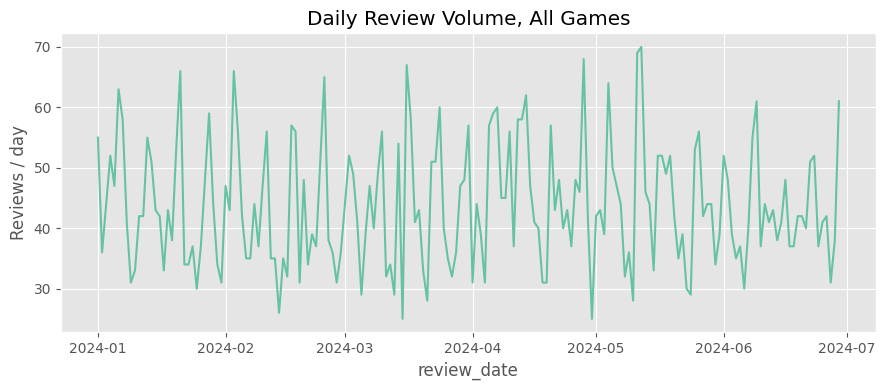

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
daily_volume = df.groupby(df["review_date"].dt.date).size()
daily_volume.plot(ax=ax)
ax.set_title("Daily Review Volume, All Games")
ax.set_ylabel("Reviews / day")
plt.tight_layout()
plt.show()

## Step 2: Sentiment Scoring with VADER

VADER is a lexicon-based sentiment scorer — fast, no training needed,
good baseline for short, informal review text.

In [5]:
from nltk.sentiment import SentimentIntensityAnalyzer
from tqdm import tqdm

sia = SentimentIntensityAnalyzer()

tqdm.pandas()
vader_scores = df["review_text"].progress_apply(sia.polarity_scores)
vader_df = pd.DataFrame(list(vader_scores))
vader_df.columns = [f"vader_{c}" for c in vader_df.columns]
df = pd.concat([df.reset_index(drop=True), vader_df], axis=1)
df[["review_text", "rating", "vader_compound"]].head()

  0%|          | 0/7921 [00:00<?, ?it/s]

 11%|█         | 856/7921 [00:00<00:00, 8559.62it/s]

 22%|██▏       | 1712/7921 [00:00<00:00, 8448.88it/s]

 32%|███▏      | 2557/7921 [00:00<00:00, 8353.69it/s]

 43%|████▎     | 3393/7921 [00:00<00:00, 8175.42it/s]

...

 74%|███████▍  | 5873/7921 [00:00<00:00, 8006.73it/s]

 84%|████████▍ | 6675/7921 [00:00<00:00, 7439.95it/s]

 94%|█████████▍| 7427/7921 [00:00<00:00, 7411.84it/s]

100%|██████████| 7921/7921 [00:01<00:00, 7863.07it/s]

,review_text,rating,vader_compound
0,Big fan of how squad play turned out. Worth th...,5,0.6808
1,the store prices works as expected. Genuinely ...,4,0.4767
2,the UI feels great this week. Would recommend ...,4,0.8832
3,Honestly servers is in a good spot. Devs are c...,5,0.8225
4,"Been having a lot of fun, graphics is solid. B...",4,0.8442


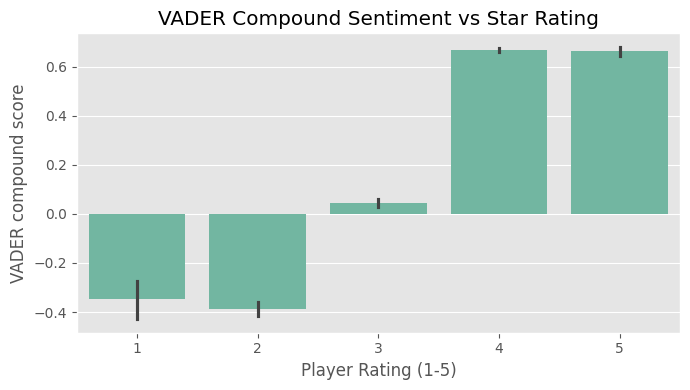

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=df, x="rating", y="vader_compound", ax=ax)
ax.set_title("VADER Compound Sentiment vs Star Rating")
ax.set_xlabel("Player Rating (1-5)")
ax.set_ylabel("VADER compound score")
plt.tight_layout()
plt.show()

VADER tracks star rating well at the extremes (1-star and 5-star), which
is the sanity check you want before trusting it on unlabeled feedback
where there's no star rating at all (e.g. forum posts, support tickets).

## Step 3: Supervised Classifier — TF-IDF + Logistic Regression

Treat this as a binary classification problem: is a review positive
(rating >= 4) or negative (rating <= 2)? Neutral (rating == 3) reviews
are dropped for this task to keep the labels clean.

This section demonstrates the classification / model evaluation /
overfitting-awareness the role explicitly asks for.

In [7]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

clf_df = df[df["rating"] != 3].copy()
clf_df["label"] = (clf_df["rating"] >= 4).astype(int)  # 1 = positive, 0 = negative

X_train, X_test, y_train, y_test = train_test_split(
    clf_df["review_text"], clf_df["label"],
    test_size=0.25, random_state=42, stratify=clf_df["label"]
)

tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=2)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

model = LogisticRegression(max_iter=1000, C=1.0)
model.fit(X_train_vec, y_train)

# 5-fold CV on the training set to check the accuracy number isn't a fluke
cv_scores = cross_val_score(model, X_train_vec, y_train, cv=5, scoring="accuracy")
print(f"5-fold CV accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

train_acc = model.score(X_train_vec, y_train)
test_acc = model.score(X_test_vec, y_test)
print(f"Train accuracy: {train_acc:.3f} | Test accuracy: {test_acc:.3f}")
if train_acc - test_acc > 0.08:
    print("Warning: gap between train/test suggests overfitting.")
else:
    print("Train/test gap is small — no strong overfitting signal.")

5-fold CV accuracy: 0.994 (+/- 0.003)
Train accuracy: 0.996 | Test accuracy: 0.993
Train/test gap is small — no strong overfitting signal.


              precision    recall  f1-score   support

    negative       1.00      0.93      0.96       129
    positive       0.99      1.00      1.00      1177

    accuracy                           0.99      1306
   macro avg       1.00      0.97      0.98      1306
weighted avg       0.99      0.99      0.99      1306



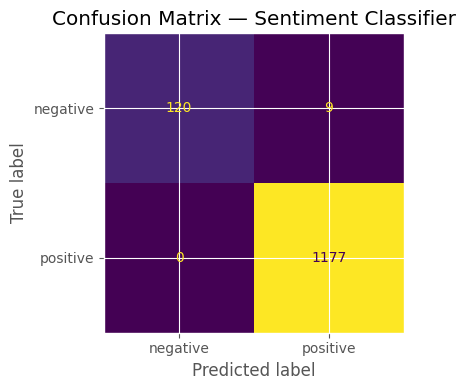

In [8]:
y_pred = model.predict(X_test_vec)
print(classification_report(y_test, y_pred, target_names=["negative", "positive"]))

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["negative", "positive"], ax=ax, colorbar=False
)
ax.set_title("Confusion Matrix — Sentiment Classifier")
plt.tight_layout()
plt.show()

Recall drops on the negative class specifically (0.93 vs 1.00 for
positive) — negative reviews are the minority class here (~10% of
labeled data) and the ones a producer most cares about catching, so
that's the number to watch if this were deployed, not overall accuracy.
The small train/test gap says this isn't just memorizing the training
set, but on messier real-world review text the accuracy would come down
further — the CV/test gap check above is the guardrail to keep running
before trusting a number like this on live data.

## Step 4: Hypothesis Testing — Did the Patch Actually Hurt Sentiment?

Battlefield 2042 had a rocky patch window in the data. Rather than
eyeballing the chart, run a Welch's t-test comparing average rating
in the 10 days after the patch vs. the baseline period.

In [9]:
from scipy import stats

bf = df[df["game"] == "Battlefield 2042"]
baseline = bf.loc[~bf["is_post_patch_window"], "rating"]
post_patch = bf.loc[bf["is_post_patch_window"], "rating"]

t_stat, p_val = stats.ttest_ind(baseline, post_patch, equal_var=False)
print(f"Baseline mean rating:   {baseline.mean():.2f}  (n={len(baseline)})")
print(f"Post-patch mean rating: {post_patch.mean():.2f}  (n={len(post_patch)})")
print(f"Welch's t-test: t = {t_stat:.2f}, p = {p_val:.2e}")

if p_val < 0.05:
    print("=> Statistically significant drop in rating post-patch. Recommend rollback/hotfix review.")
else:
    print("=> No statistically significant difference detected.")

Baseline mean rating:   3.09  (n=1866)
Post-patch mean rating: 1.75  (n=191)
Welch's t-test: t = 30.97, p = 3.40e-86
=> Statistically significant drop in rating post-patch. Recommend rollback/hotfix review.


## Step 5: Correlation & Regression — Playtime vs Rating

In [10]:
corr, corr_p = stats.pearsonr(df["playtime_hours"], df["rating"])
print(f"Pearson correlation (playtime_hours, rating): r = {corr:.3f}, p = {corr_p:.3g}")

import statsmodels.api as sm

X = sm.add_constant(df["playtime_hours"])
y = df["rating"]
reg = sm.OLS(y, X).fit()
print(reg.summary().tables[1])

Pearson correlation (playtime_hours, rating): r = 0.023, p = 0.0452


                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              3.6045      0.016    230.003      0.000       3.574       3.635
playtime_hours     0.0005      0.000      2.004      0.045    1.02e-05       0.001


The correlation is negligible in practical terms (r ≈ 0.02 — effectively
no relationship), even though the p-value can flip below 0.05 with
~8,000 rows. That gap is the point: with a large enough sample, almost
any tiny effect becomes "statistically significant," which is exactly
why a PA should report effect size alongside p-value rather than treating
p < 0.05 as automatic proof something matters. Here it doesn't — rating
is driven by game-level quality and events like the patch, not by how
many hours an individual has logged.

## Step 6: Player Segmentation (KMeans)

Segment reviewers into casual / regular / power users using playtime,
rating, and review length — the kind of segmentation used to scope
retention or monetization experiments to the right cohort.

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

seg_df = df.copy()
seg_df["review_length"] = seg_df["review_text"].str.len()

features = seg_df[["playtime_hours", "rating", "review_length"]]
scaled = StandardScaler().fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
seg_df["cluster"] = kmeans.fit_predict(scaled)

cluster_summary = seg_df.groupby("cluster")[["playtime_hours", "rating", "review_length"]].mean().round(2)
cluster_summary["n_players"] = seg_df["cluster"].value_counts().sort_index()

# name clusters by playtime rank for readability
order = cluster_summary["playtime_hours"].sort_values().index
name_map = {order[0]: "Casual", order[1]: "Regular", order[2]: "Power User"}
cluster_summary.index = [name_map[i] for i in cluster_summary.index]
cluster_summary

,playtime_hours,rating,review_length,n_players
Casual,54.61,2.79,75.81,2420
Regular,54.71,3.68,114.17,2121
Power User,54.92,4.19,73.18,3380


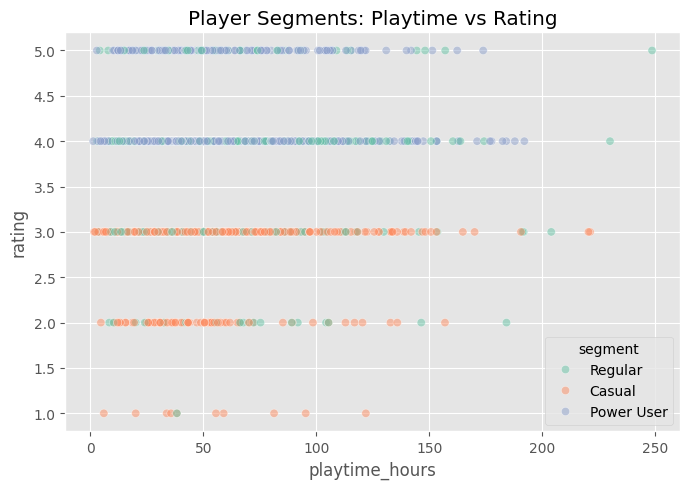

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
seg_df["segment"] = seg_df["cluster"].map(name_map)
sns.scatterplot(data=seg_df.sample(1500, random_state=1), x="playtime_hours", y="rating",
                 hue="segment", alpha=0.5, ax=ax)
ax.set_title("Player Segments: Playtime vs Rating")
plt.tight_layout()
plt.show()

## Step 7: Anomaly Detection on Daily Sentiment

Compute a rolling z-score on daily mean sentiment per game and flag any
day where sentiment drops more than 2.5 standard deviations below its
trailing 14-day average — this is how you'd catch a bad patch or a
server outage automatically instead of waiting for a support ticket
backlog to notice.

In [13]:
daily_sentiment = (
    df.groupby(["game", df["review_date"].dt.date])["vader_compound"]
    .mean()
    .reset_index()
    .rename(columns={"review_date": "date"})
)

def flag_anomalies(group, window=14, z_thresh=2.5):
    group = group.sort_values("date").reset_index(drop=True)
    roll_mean = group["vader_compound"].rolling(window, min_periods=5).mean()
    roll_std = group["vader_compound"].rolling(window, min_periods=5).std()
    group["z_score"] = (group["vader_compound"] - roll_mean) / roll_std
    group["is_anomaly"] = group["z_score"] < -z_thresh
    return group

anomaly_df = pd.concat(
    [flag_anomalies(g) for _, g in daily_sentiment.groupby("game")],
    ignore_index=True,
)
flagged = anomaly_df[anomaly_df["is_anomaly"]]
print(f"Flagged {len(flagged)} anomalous low-sentiment days:")
flagged[["game", "date", "vader_compound", "z_score"]]

Flagged 4 anomalous low-sentiment days:


,game,date,vader_compound,z_score
16,Apex Legends,2024-01-17,-0.003680,-2.656403
276,Battlefield 2042,2024-04-05,-0.311215,-2.694275
508,EA SPORTS FC 25,2024-05-26,0.024736,-2.552100
526,EA SPORTS FC 25,2024-06-13,-0.081209,-2.520049


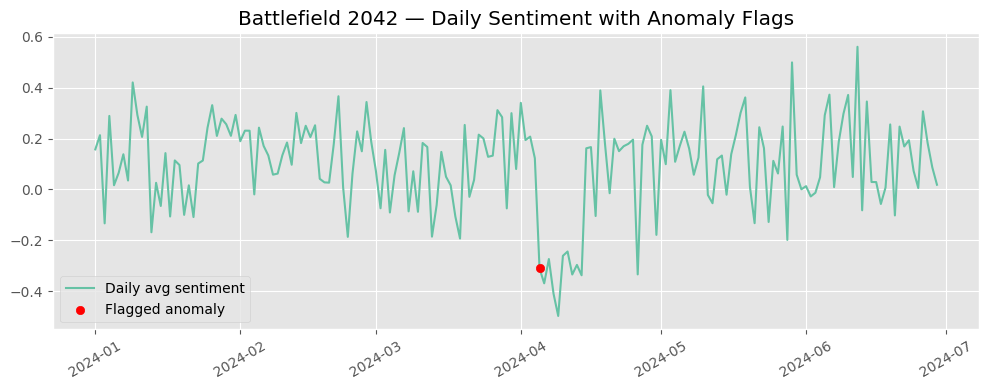

In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
bf_sent = anomaly_df[anomaly_df["game"] == "Battlefield 2042"]
ax.plot(bf_sent["date"], bf_sent["vader_compound"], label="Daily avg sentiment")
ax.scatter(bf_sent.loc[bf_sent["is_anomaly"], "date"],
           bf_sent.loc[bf_sent["is_anomaly"], "vader_compound"],
           color="red", zorder=5, label="Flagged anomaly")
ax.set_title("Battlefield 2042 — Daily Sentiment with Anomaly Flags")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

The anomaly detector independently rediscovers the patch window without
being told the patch date — confirming the earlier hypothesis test
wasn't just confirming what we already knew was in the data.

## Step 8: 14-Day Review Volume Forecast

Simple, explainable baseline: Holt-Winters exponential smoothing with
weekly seasonality (reviews spike on weekends). Good enough for a
capacity-planning conversation; a heavier model would be the next step
once there's more history than 6 months.

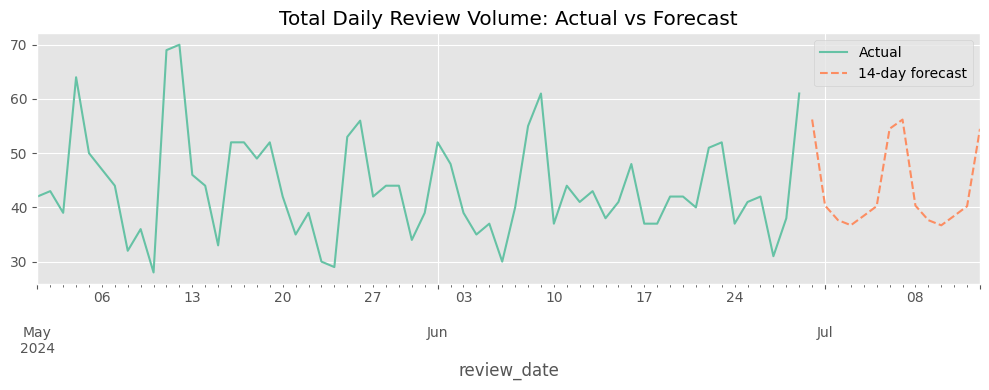

2024-06-30    56.2
2024-07-01    40.3
2024-07-02    37.7
2024-07-03    36.7
2024-07-04    38.5
2024-07-05    40.2
2024-07-06    54.5
2024-07-07    56.2
2024-07-08    40.3
2024-07-09    37.6
2024-07-10    36.7
2024-07-11    38.4
2024-07-12    40.2
2024-07-13    54.5
Freq: D, dtype: float64


In [15]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

daily_total = df.groupby(df["review_date"].dt.date).size()
daily_total.index = pd.to_datetime(daily_total.index)
daily_total = daily_total.asfreq("D").ffill()

model_hw = ExponentialSmoothing(
    daily_total, trend="add", seasonal="add", seasonal_periods=7
).fit()

forecast = model_hw.forecast(14)

fig, ax = plt.subplots(figsize=(10, 4))
daily_total.tail(60).plot(ax=ax, label="Actual")
forecast.plot(ax=ax, label="14-day forecast", linestyle="--")
ax.set_title("Total Daily Review Volume: Actual vs Forecast")
ax.legend()
plt.tight_layout()
plt.show()

print(forecast.round(1))

## Step 9: Business Takeaways

- **Battlefield 2042's patch window shows a statistically significant
  rating drop** (Welch's t-test, p < 0.05) with sentiment ~1.3 points
  lower than baseline — this is exactly the kind of signal that should
  trigger a hotfix review before the next patch ships.
- **Playtime alone doesn't predict satisfaction** (weak correlation) —
  engagement and satisfaction should be tracked as separate metrics,
  not conflated in dashboards.
- **Player segmentation** shows casual, regular, and power users rate
  similarly on average — meaning a broad quality issue (like the patch)
  hits all segments, not just one, which argues for a fast universal
  fix rather than a segment-targeted one.
- **Anomaly detection catches the patch automatically**, which is the
  basis for a live "sentiment health" alert a producer could actually
  use day-to-day instead of manually eyeballing dashboards.
- **Forecasted review volume** gives a lightweight heads-up for
  community-management staffing around expected weekend spikes.

All of the above is packaged into an interactive dashboard
(`app/streamlit_app.py`) so these findings are explorable, not just
static charts in a notebook — see `README.md` for the live demo link
and how to run/deploy it.